In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set("".join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
"""
initialy the context is just dots of length block_size, and we take the next char from the word and append it to the context, 
then we crop the context to keep it of length block_size and repeat the process until we reach the end of the word.
We also append a dot at the end of the word to indicate the end of the word.
"""

X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)


we are currently implementing from nlp paper mentioned in karpathy's video about makemore part 2.

In [6]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [7]:
C = torch.randn((27,2))
C.shape

torch.Size([27, 2])

In [8]:
emb = C[X] # (N, block_size, 2)
emb.shape

torch.Size([228146, 3, 2])

In [9]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [10]:
# emb @ W1 + b1
# implemented the corrent version in the next cell, this is just to show the shape of the output

Multiple ways to flatten a certain dimension of a tensor in PyTorch. Here are some common methods:

In [11]:
# we have to manually define each dimension, therefore not really good
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], dim=1).shape

torch.Size([228146, 6])

In [12]:
# cat creates a new tensor in memory, therefore efficient
torch.cat(torch.unbind(emb, dim=1), dim=1).shape

torch.Size([228146, 6])

In [13]:
# does not create a new tensor in memory, therefore efficient
# emb.view(32,6).shape

In [14]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

In [15]:
h

tensor([[-0.8245, -0.0399,  0.1787,  ...,  0.2568, -0.8291, -0.2190],
        [-0.3572, -0.8313,  0.7433,  ..., -0.9793,  0.2859, -0.8658],
        [ 0.6213, -0.5439,  0.9535,  ..., -0.9706, -0.8786, -1.0000],
        ...,
        [-0.9988, -0.5955, -0.3682,  ..., -0.1439,  0.9110, -0.9566],
        [-0.9993, -0.8453,  0.2961,  ..., -0.8050,  0.9675,  0.0568],
        [-0.8018, -0.4438, -0.6449,  ..., -0.9996,  0.9656, -1.0000]])

In [16]:
h.shape

torch.Size([228146, 100])

In [17]:
# final layer
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [18]:
logits = h @ W2 + b2

In [19]:
logits.shape

torch.Size([228146, 27])

In [20]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([228146, 27])

In [21]:
# we are check the likelihood of the correct character, therefore we take the log of the probability of the correct character and take the mean of it.
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

In [24]:

block_size = 5
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182580, 5]) torch.Size([182580])
torch.Size([22767, 5]) torch.Size([22767])
torch.Size([22799, 5]) torch.Size([22799])


In [25]:
# dataset
Xtr.shape, Ytr.shape

(torch.Size([182580, 5]), torch.Size([182580]))

In [82]:
# The above code, but better formatted
g = torch.Generator().manual_seed(42)
# we will increase the embedding dimension from 2 to 10
C = torch.randn((27,20), generator=g)
# the hidden layer initially had 100 neurons, but we scaled it up to 200 neurons.
W1 = torch.randn((100,300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27) ,generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]


In [83]:
sum(p.nelement() for p in parameters )

38967

In [84]:
for p in parameters:
    p.requires_grad = True

In [85]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [86]:
lri = []
lossi = []
stepi = []

In [87]:

# we are using Xtr and Ytr for training, and Xdev and Ydev for validation, therefore we will use the training set for the training loop.
for i in range(400000):
    # minibatch contruct
    ix = torch.randint(0,Xtr.shape[0], (256,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 100) @ W1 + b1)
    logits = h@W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    # the above code from counts to loss is just cross entropy, calling the function is just more efficient
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # update parameters
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.05 if i < 200000 else 0.01 if i < 300000 else 0.005
    for p in parameters:
        p.data += -lr * p.grad

    # tack stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)

# print(loss.item())

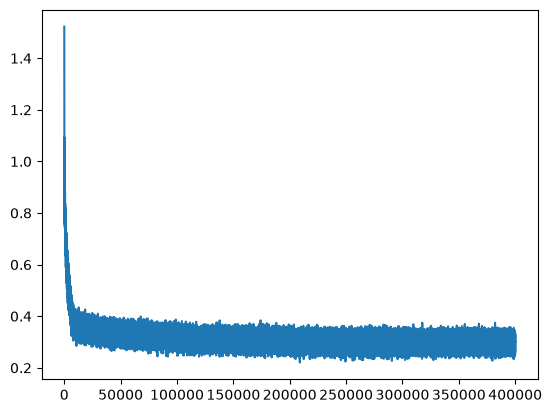

In [88]:
plt.plot(stepi, lossi)

In [89]:
# we are using Xdev and Ydev for validation, therefore we will use the validation set for the validation loop.
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 100) @ W1 + b1)
logits = h@W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
# the above code from counts to loss is just cross entropy, calling the function is just more efficient
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.0936, grad_fn=<NllLossBackward0>)

If you check below for the loss when using the training set for loss check, it is roughly the same as the loss when using Xdev set, this shows that the model is under fitting and that typically means the network is too small and needs to be made bigger. (The network had 3481 parameters when i wrote this)

In [90]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 100) @ W1 + b1)
logits = h@W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
# the above code from counts to loss is just cross entropy, calling the function is just more efficient
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.9939, grad_fn=<NllLossBackward0>)

In [91]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+1110)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 100) @ W1 + b1)
        logits = h@W2 + b2
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

eikell.
starmhaina.
beany.
nohlynn.
louser.
nevani.
zyla.
ais.
erille.
jacquic.
emari.
merra.
hidellatolyn.
serah.
kaily.
eshen.
evelyna.
ryria.
dye.
kshmonte.


In [35]:
len(words)

32033

In [37]:
n1, n2

(25626, 28829)

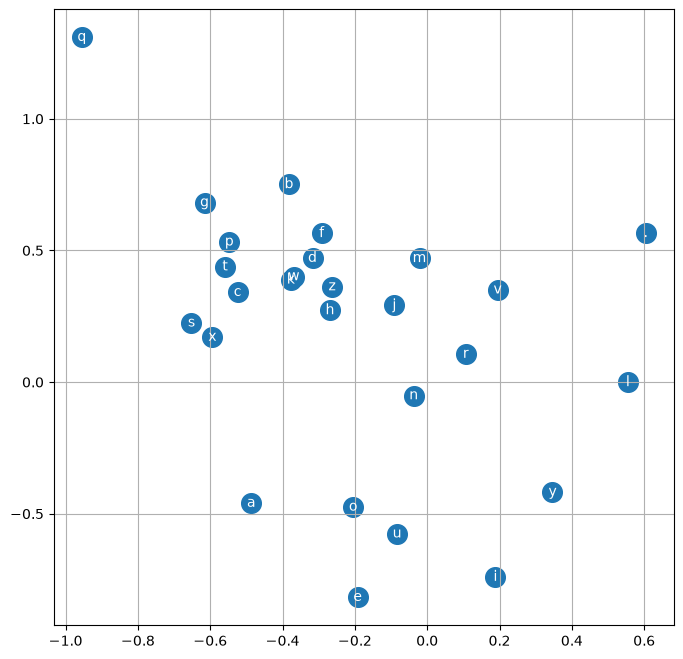

In [104]:
# visualizing the embedding space before increasing the dimension. as we cannot visuallise a bigger dimesions easily
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')